1. Importing the library

In [156]:
import sklearn # Import library
import pandas as pd
from sklearn.linear_model import LinearRegression # Import class from specific model


2. Loading the data

In [157]:
from sklearn.datasets import load_iris, make_classification, make_regression

# Create synthetic classification dataset
data_classification = make_classification(n_samples=1000, n_features=10, n_informative=7, random_state=42)

# Create synthetic regression dataset
data_regression = make_regression(n_samples=5000, n_features=8, n_informative=4, random_state=42)

# We'll use classification data by default
data = data_classification


3. Splitting the data into a training set and a test set


In [158]:
from sklearn.model_selection import train_test_split

# Split classification data
X_class, y_class = data_classification
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X_class, y_class, test_size=0.2, random_state=0)

# Split regression data
X_reg, y_reg = data_regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=0)

# Use classification data for subsequent preprocessing steps
X_train = X_train_class
X_test = X_test_class
y_train = y_train_class
y_test = y_test_class


In [159]:
#from sklearn.model_selection import train_test_split

# Create DataFrame from the data
#X, y = data
#df = pd.DataFrame(X)
#df["target"] = y

# Split data into train and test set
#X = df.drop("target", axis=1)
#y = df["target"]
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


4. Preparing the data

4.1. Normalizing training and test data;

In [160]:
# Get normalized features

from sklearn.preprocessing import Normalizer

# For classification data
normalizer_class = Normalizer().fit(X_train_class)
normalized_X_train_class = normalizer_class.transform(X_train_class)
normalized_X_test_class = normalizer_class.transform(X_test_class)

# For regression data
normalizer_reg = Normalizer().fit(X_train_reg)
normalized_X_train_reg = normalizer_reg.transform(X_train_reg)
normalized_X_test_reg = normalizer_reg.transform(X_test_reg)


4.2. Standardizing training and test data:

In [161]:
# Get standardized features

from sklearn.preprocessing import StandardScaler

# For classification data
scaler_class = StandardScaler()
X_train_std_class = scaler_class.fit_transform(X_train_class)
X_test_std_class = scaler_class.transform(X_test_class)

# For regression data
scaler_reg = StandardScaler()
X_train_std_reg = scaler_reg.fit_transform(X_train_reg)
X_test_std_reg = scaler_reg.transform(X_test_reg)


4.3. Binarizing data

In [162]:
# Get boolean values from features based on threshold. If threshold is 0, then all numbers above 0 are converted to 1 and others to 0.

from sklearn.preprocessing import Binarizer

# For classification data
binarizer_class = Binarizer(threshold=0.0).fit(X_class)
binarized_X_class = binarizer_class.transform(X_class)

# For regression data
binarizer_reg = Binarizer(threshold=0.0).fit(X_reg)
binarized_X_reg = binarizer_reg.transform(X_reg)


4.4. Generating polynomial features

In [163]:
# Get polynomial features based on given degree

from sklearn.preprocessing import PolynomialFeatures

# For classification data
poly_class = PolynomialFeatures(degree=2)
X_train_poly_class = poly_class.fit_transform(X_train_class)
X_test_poly_class = poly_class.transform(X_test_class)

# For regression data
poly_reg = PolynomialFeatures(degree=2)
X_train_poly_reg = poly_reg.fit_transform(X_train_reg)
X_test_poly_reg = poly_reg.transform(X_test_reg)


4.5. Encoding categorical variables


In [164]:
# Get labels for categorical data

from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_class)


4.6. Completing empty values:


In [165]:
# Impute missing values with given strategy

from sklearn.impute import SimpleImputer

# For classification data
imputer_class = SimpleImputer(
    missing_values=0,
    strategy="most_frequent"
)
X_imputed_class = imputer_class.fit_transform(X_class)

# For regression data
imputer_reg = SimpleImputer(
    missing_values=0,
    strategy="mean"
)
X_imputed_reg = imputer_reg.fit_transform(X_reg)


5. Creating the model

In [166]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
log_reg_model = LogisticRegression()
lr = LinearRegression()
knn = KNeighborsClassifier(n_neighbors=3)

6. Fitting the model to the training data

6.1. Supervised Learning

In [167]:
# Linear regression with regression data
lr.fit(X_train_reg, y_train_reg)




,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [168]:
# Classifiers with classification data
log_reg_model.fit(X_train_class, y_train_class)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [169]:
# Classifiers with classification data
knn.fit(X_train_class, y_train_class)


,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


6.2. Unsupervised learning


In [170]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

k_means_model = KMeans(n_clusters=3)
pca_model = PCA(n_components=2)

k_means_model.fit(X_train_class)
pca_model.fit_transform(X_train_class)


c:\Users\UrosVukmanovic\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


array([[-1.6735676 , -4.41887289],
       [ 1.58246163,  0.07580023],
       [ 0.61898142,  8.02184824],
       ...,
       [ 0.65532321, -0.2855191 ],
       [-2.33182523, -1.53766341],
       [-2.32813939, -2.94467562]], shape=(800, 2))

7. Model prediction on test data

7.1. Supervised learning

In [171]:
# 7.1. Supervised learning
import numpy as np

y_pred_class = log_reg_model.predict(np.random.random((3, 10))) # predict specific labels
y_pred_reg = lr.predict(X_test_reg) # predict specific labels za REGRESIJU
y_pred_proba = knn.predict_proba(X_test_class) # estimate probability of a label

7.2. Unsupervised learning


In [172]:
# Make predictions using fitted models
y_pred = k_means_model.predict(X_test_class)



8. Evaluating the quality of the model 

8.1. Classification models:

In [173]:
# Accuracy:
# You can measure accuracy using estimator score method or metric function

knn.score(X_test_class, y_test_class)
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)


0.51

In [174]:
# Classification report:
from sklearn.metrics import classification_report # It returns precision, recall, f1-score and support
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.83      0.68      0.75        85
           1       0.94      0.38      0.54       115
           2       0.00      0.00      0.00         0

    accuracy                           0.51       200
   macro avg       0.59      0.35      0.43       200
weighted avg       0.89      0.51      0.63       200



c:\Users\UrosVukmanovic\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\UrosVukmanovic\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\UrosVukmanovic\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [175]:
# Confusion matrix:
# Get confusion matrix for classification model

from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))


[[58  3 24]
 [12 44 59]
 [ 0  0  0]]


8.2. Regression models


In [176]:
# Mean absolute error:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test_reg, y_pred_reg)


4.0903891385113413e-14

In [177]:
# Mean squared error:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test_reg, y_pred_reg)

2.69715669299228e-27

In [178]:
# R2
from sklearn.metrics import r2_score
r2_score(y_test_reg, y_pred_reg)

# underfiting model or bad data


1.0

In [179]:
# Cross-validation:
# Calculate metric for every cross-validation split

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

# KREIRAJTE NOVI MODEL - NE KORISTITE lr koji je već treniran!
lr_cv = LinearRegression()

scores = cross_val_score(lr_cv, X_reg, y_reg, cv=5)
print(scores)

[1. 1. 1. 1. 1.]


Comment on 8. Evaluating the quality of the model

The Issue Explained
Your regression model achieves R² ≈ 1.0 (perfect or near-perfect scores) because:

Synthetic Data is Too Simple

You're using make_regression() which creates artificially perfect linear relationships
Only 4 out of 8 features are informative (n_informative=4)
LinearRegression can fit this data almost perfectly
No Noise in Data

Your original data has no noise parameter
In real-world data, there's always some randomness/error
Without noise, linear regression achieves near-perfect predictions


9. Fine-tuning


In [180]:
# Grid search:

# Grid search for classification:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid
param_grid = {
    "C": [0.1, 1, 10, 100],
    "penalty": ["l1", "l2"]
}

# Create grid search object with LogisticRegression
grid = GridSearchCV(log_reg_model, param_grid, cv=5)

# Fit on training data (NOT raw data)
grid.fit(X_train_class, y_train_class)

# Print best parameters and score
print(f"Best parameters: {grid.best_params_}")
print(f"Best cross-validation score: {grid.best_score_:.4f}")

# Use best model for predictions
best_model = grid.best_estimator_
y_pred_grid = best_model.predict(X_test_class)


Best parameters: {'C': 1, 'penalty': 'l2'}
Best cross-validation score: 0.8050


c:\Users\UrosVukmanovic\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
20 fits failed out of a total of 40.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\UrosVukmanovic\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\UrosVukmanovic\anaconda3\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\UrosVukmanovic\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.p

Key fixes:

Use correct model - log_reg_model (LogisticRegression) not undefined model
Use training data - X_train_class, y_train_class not raw X, y
Add results output - Print best parameters and scores
Extract best model - Use grid.best_estimator_ for predictions
What Grid Search does:

Tests all combinations of hyperparameters
Evaluates each with cross-validation (cv=5)
Finds the best combination automatically
Saves best model in grid.best_estimator_

In [181]:
# Randomized search:
from sklearn.model_selection import RandomizedSearchCV
params = {"n_neighbors": range(1, 8)}
random_search = RandomizedSearchCV(estimator=knn,
                                   param_distributions=params,
                                   cv=5,
                                   random_state=42)


10. Extras


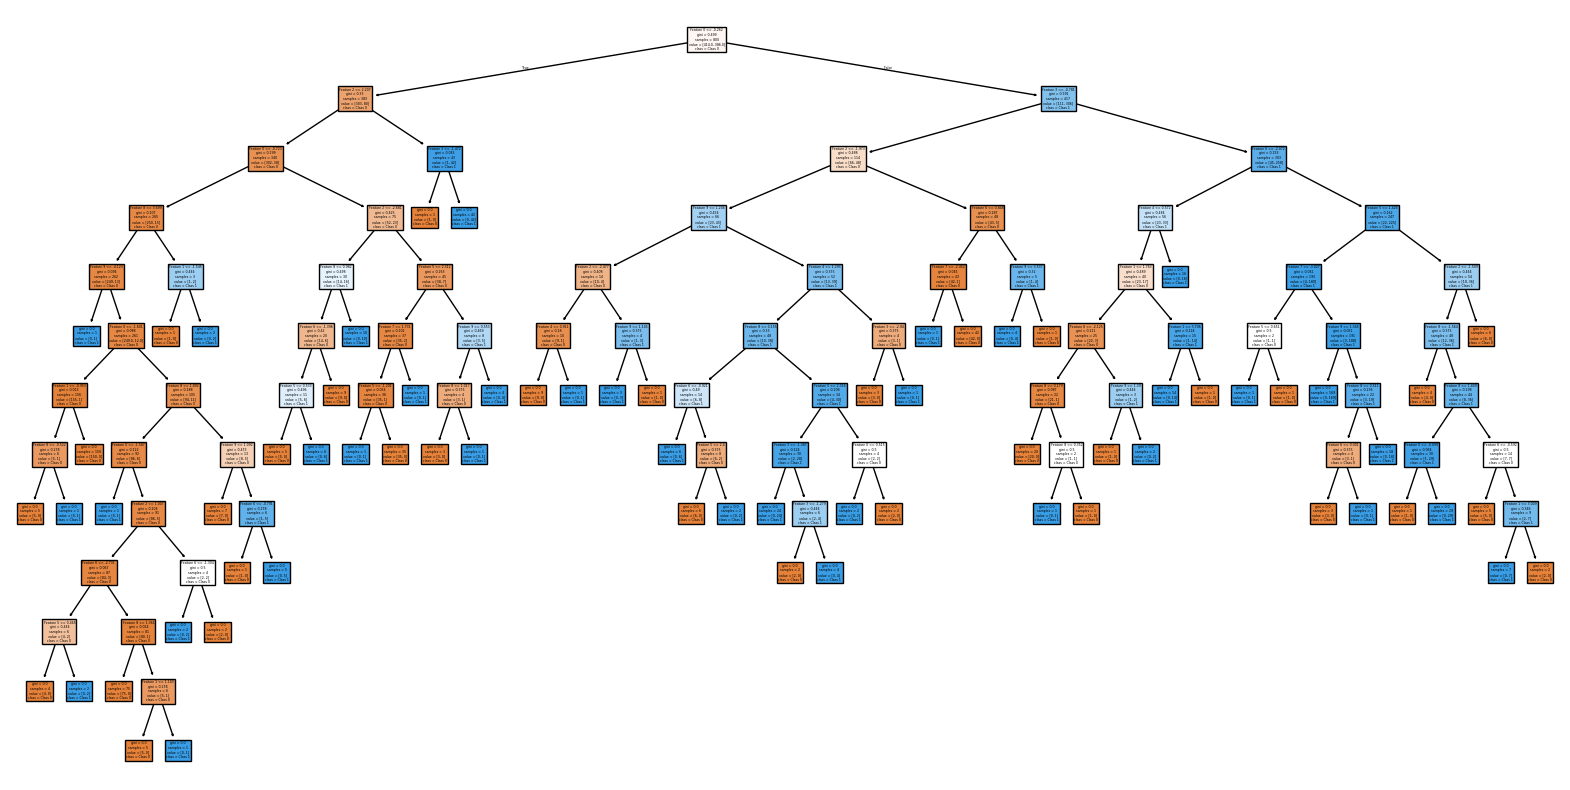

In [182]:
# Decision tree visualization:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Create and train a decision tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_class, y_train_class)

# Visualize the decision tree
plt.figure(figsize=(20, 10))
plot_tree(dt_model, filled=True, feature_names=[f"Feature {i}" for i in range(X_train_class.shape[1])], class_names=["Class 0", "Class 1"])
plt.show()

In [184]:
# Saving and loading a model
import joblib
joblib.dump(dt_model, "model.pkl")
model = joblib.load("model.pkl")
